In [1]:
#import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [50]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/student_performance.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [29]:
df.shape

(639, 2)

In [30]:
df.head()

,study_hours,exam_score
0,1.2,42
1,8.5,95
2,5.4,78
3,3.1,55
4,9.8,99


In [31]:
df.describe()

,study_hours,exam_score
count,639.000000,639.000000
mean,4.998592,74.001565
std,2.746291,20.930509
min,0.100000,31.000000
25%,2.700000,57.000000
50%,5.000000,76.000000
75%,7.300000,93.000000
max,9.900000,100.000000


In [32]:
df.isnull().sum()

,0
study_hours,0
exam_score,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  639 non-null    float64
 1   exam_score   639 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 10.1 KB


In [51]:
df.columns

Index(['study_hours', 'exam_score'], dtype='object')

In [52]:
print("Number of duplicate records: ",df.duplicated().sum())

Number of duplicate records:  230


In [53]:
df.drop_duplicates(inplace=True)
print(f"Duplicate rows removed. New DataFrame shape: {df.shape}")

Duplicate rows removed. New DataFrame shape: (409, 2)


In [55]:
df['study_hours']=df["study_hours"].apply(np.floor)
df.head()

,study_hours,exam_score
0,1.0,42
1,8.0,95
2,5.0,78
3,3.0,55
4,9.0,99


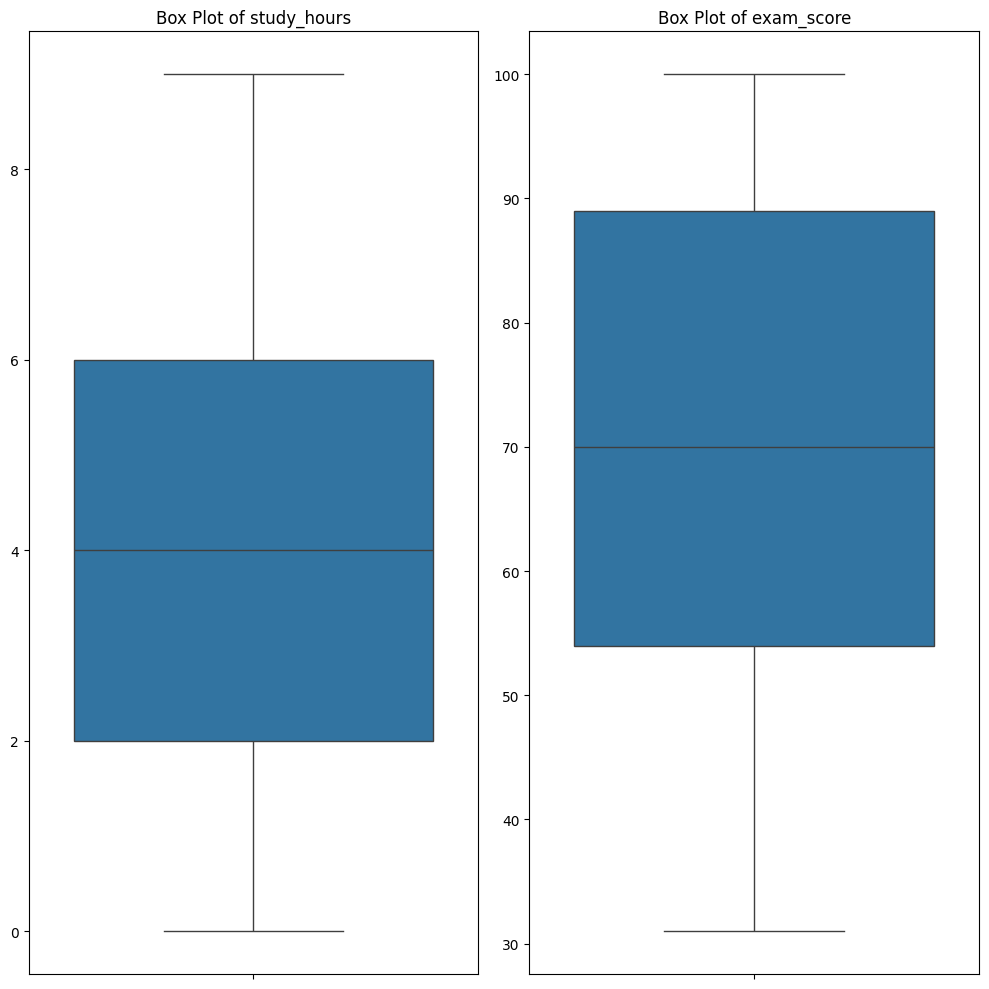

In [58]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [14]:
# Calculate IQR for 'study_hours'
Q1_hours = df['study_hours'].quantile(0.25)
Q3_hours = df['study_hours'].quantile(0.75)
IQR_hours = Q3_hours - Q1_hours

# Define bounds for 'study_hours' outliers
lower_bound_hours = Q1_hours - 1.5 * IQR_hours
upper_bound_hours = Q3_hours + 1.5 * IQR_hours

# Calculate IQR for 'exam_score'
Q1_score = df['exam_score'].quantile(0.25)
Q3_score = df['exam_score'].quantile(0.75)
IQR_score = Q3_score - Q1_score

# Define bounds for 'exam_score' outliers
lower_bound_score = Q1_score - 1.5 * IQR_score
upper_bound_score = Q3_score + 1.5 * IQR_score

print(f"Study Hours Outlier Bounds: ({lower_bound_hours:.2f}, {upper_bound_hours:.2f})")
print(f"Exam Score Outlier Bounds: ({lower_bound_score:.2f}, {upper_bound_score:.2f})")

Study Hours Outlier Bounds: (-3.85, 12.55)
Exam Score Outlier Bounds: (1.50, 141.50)


In [59]:
# Identify and remove outliers
df_no_outliers = df[
    (df['study_hours'] >= lower_bound_hours) & (df['study_hours'] <= upper_bound_hours) &
    (df['exam_score'] >= lower_bound_score) & (df['exam_score'] <= upper_bound_score)
]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")

# Assign the cleaned DataFrame back to df for subsequent steps
df = df_no_outliers.copy()

Original DataFrame shape: (409, 2)
DataFrame shape after outlier removal: (409, 2)


In [16]:
x = df.iloc[:, :-1]
print(f"Shape of x after deduplication: {x.shape}")

Shape of x after deduplication: (409, 1)


In [17]:
y = df.iloc[:, -1]
print(f"Shape of y after deduplication: {y.shape}")

Shape of y after deduplication: (409,)


In [60]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Data Splitted Successfully")

Data Splitted Successfully


In [61]:
model=LinearRegression()
print(" Model created")

 Model created


In [21]:
model.fit(x_train,y_train)
print("Model Trained")

Model Trained


In [22]:
#Generate predictions for training and testing datasets using the trained model
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print("Predictions generated for both training and testing datasets")

Predictions generated for both training and testing datasets


In [23]:
#Metrics calculation on training data
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 2.148325506190932
Mean Squared Error (MSE): 7.855053650493726
Root MSE (RMSE): 2.8026868627254324
R2 Score: 0.9798137382454644


In [24]:
#Metrics calculation on testing data
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 2.33876592698037
Mean Squared Error (MSE): 12.207966209633925
Root MSE (RMSE): 3.493990012812562
R2 Score: 0.9706311225878177


In [25]:
model.coef_

array([7.92488782])

In [26]:
model.intercept_

np.float64(35.29253023631803)

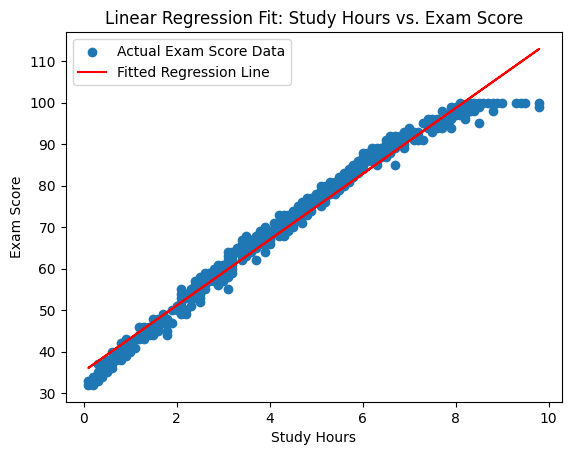

In [ ]:
plt.scatter(x_train, y_train, label='Actual Exam Score Data')
plt.plot(x_train, y_pred_train, color='red', label='Fitted Regression Line')
plt.xlabel('Study Hours'); plt.ylabel('Exam Score')
plt.title('Linear Regression Fit on Train Data: Study Hours vs. Exam Score')
plt.legend()
plt.show()

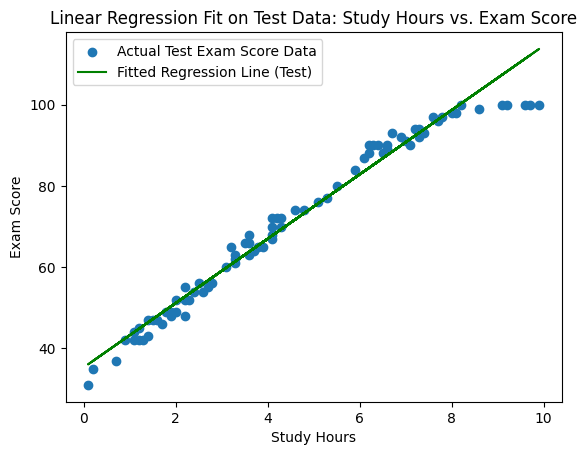

In [ ]:
plt.scatter(x_test, y_test, label='Actual Test Exam Score Data')
plt.plot(x_test, y_pred_test, color='green', label='Fitted Regression Line (Test)')
plt.xlabel('Study Hours'); plt.ylabel('Exam Score')
plt.title('Linear Regression Fit on Test Data: Study Hours vs. Exam Score')
plt.legend()
plt.show()